In [124]:
from pathlib import Path
import re
import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import display
from langchain_text_splitters import (
    CharacterTextSplitter,
    MarkdownHeaderTextSplitter,
    RecursiveCharacterTextSplitter
)
from langchain_text_splitters.base import TextSplitter

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [125]:
# Localiza a pasta AULA_04

PASTA_AULA_04 = Path.cwd()

if PASTA_AULA_04.name != "AULA_04":
    PASTA_AULA_04 = PASTA_AULA_04 / "AULA_04"

if not PASTA_AULA_04.exists():
    raise FileNotFoundError(
        f"A pasta AULA_04 não foi encontrada: {PASTA_AULA_04}"
    )

# Seleciona somente os arquivos Markdown da base
arquivos_markdown = sorted(
    arquivo
    for arquivo in PASTA_AULA_04.glob("*.md")
    if arquivo.name.lower() != "readme.md"
)

if not arquivos_markdown:
    raise FileNotFoundError(
        f"Nenhum Markdown encontrado em {PASTA_AULA_04}"
    )

documentos = {}

for arquivo in arquivos_markdown:
    documentos[arquivo.name] = arquivo.read_text(
        encoding="utf-8"
    )

print("Pasta da Aula 04:", PASTA_AULA_04)
print("Quantidade de arquivos:", len(documentos))
print()
print("Arquivos encontrados:")

for nome, conteudo in documentos.items():
    print(f"- {nome}: {len(conteudo):,} caracteres")

Pasta da Aula 04: c:\Users\Fernanda Fregulha\Downloads\IA\IA\AULA_04
Quantidade de arquivos: 12

Arquivos encontrados:
- attention_is_all_you_need.md: 48,957 caracteres
- bert_pretraining.md: 70,235 caracteres
- bioetica_e_ia.md: 51,213 caracteres
- escrita_academica_ia.md: 42,678 caracteres
- gpt3_language_models.md: 333,822 caracteres
- gpt4_technical_report.md: 289,542 caracteres
- instruct_gpt.md: 220,009 caracteres
- llama_foundation_models.md: 105,322 caracteres
- lora_low_rank_adaptation.md: 99,729 caracteres
- retrieval_augmented_generation.md: 71,960 caracteres
- scaling_laws_llm.md: 99,929 caracteres
- twitter_algoritmo.md: 54,440 caracteres


In [126]:
def contar_tabelas_markdown(texto):
    """
    Conta tabelas Markdown pela linha separadora
    localizada abaixo do cabeçalho.
    """
    linhas = texto.splitlines()
    quantidade = 0

    padrao_separador = re.compile(
        r"^\s*\|?\s*:?-{3,}:?\s*"
        r"(\|\s*:?-{3,}:?\s*)+\|?\s*$"
    )

    for linha in linhas:
        if padrao_separador.match(linha):
            quantidade += 1

    return quantidade


analise_conversao = []

for arquivo, conteudo in documentos.items():
    quantidade_titulos = len(
        re.findall(
            r"^#{1,6}\s+.+$",
            conteudo,
            flags=re.MULTILINE
        )
    )

    placeholders_imagem = len(
        re.findall(
            r"<!--\s*image\s*-->",
            conteudo,
            flags=re.IGNORECASE
        )
    )

    imagens_referenciadas = len(
        re.findall(
            r"!\[[^\]]*\]\([^)]+\)",
            conteudo
        )
    )

    tabelas_markdown = contar_tabelas_markdown(
        conteudo
    )

    formulas_blocos = conteudo.count("$$") // 2

    analise_conversao.append({
        "Arquivo": arquivo,
        "Caracteres": len(conteudo),
        "Palavras": len(conteudo.split()),
        "Títulos": quantidade_titulos,
        "Tabelas Markdown": tabelas_markdown,
        "Placeholders de imagem": placeholders_imagem,
        "Imagens referenciadas": imagens_referenciadas,
        "Blocos de fórmula": formulas_blocos
    })


df_qualidade_conversao = pd.DataFrame(
    analise_conversao
)

df_qualidade_conversao

,Arquivo,Caracteres,Palavras,Títulos,Tabelas Markdown,Placeholders de imagem,Imagens referenciadas,Blocos de fórmula
0,attention_is_all_you_need.md,48957,6648,27,4,6,0,0
1,bert_pretraining.md,70235,10375,33,8,5,0,0
2,bioetica_e_ia.md,51213,7354,24,0,4,0,0
3,escrita_academica_ia.md,42678,6108,20,2,8,0,0
4,gpt3_language_models.md,333822,41039,57,49,34,0,0
5,gpt4_technical_report.md,289542,42502,213,11,29,0,0
6,instruct_gpt.md,220009,30781,132,26,24,0,0
7,llama_foundation_models.md,105322,15750,54,17,2,0,0
8,lora_low_rank_adaptation.md,99729,15731,40,18,8,0,0
9,retrieval_augmented_generation.md,71960,10379,35,7,4,0,0


In [127]:
class ParagraphTextSplitter(TextSplitter):
    """
    Um chunk para cada parágrafo não vazio.
    """

    def split_text(
        self,
        text: str
    ) -> list[str]:
        paragrafos = re.split(
            r"\n\s*\n",
            text
        )

        return [
            paragrafo.strip()
            for paragrafo in paragrafos
            if paragrafo.strip()
        ]

In [128]:
class ThreeSentenceTextSplitter(TextSplitter):
    """
    Identifica sentenças e agrupa três
    sentenças em cada chunk.
    """

    def split_text(
        self,
        text: str
    ) -> list[str]:
        texto_normalizado = re.sub(
            r"\s+",
            " ",
            text
        ).strip()

        sentencas = re.split(
            r"(?<=[.!?])\s+",
            texto_normalizado
        )

        sentencas = [
            sentenca.strip()
            for sentenca in sentencas
            if sentenca.strip()
        ]

        chunks = []

        for indice in range(
            0,
            len(sentencas),
            3
        ):
            grupo = sentencas[
                indice:indice + 3
            ]

            chunks.append(
                " ".join(grupo)
            )

        return chunks

In [129]:
resumo_conversao = pd.DataFrame({
    "Métrica": [
        "Arquivos convertidos",
        "Total de caracteres",
        "Total de palavras",
        "Total de títulos",
        "Total de tabelas Markdown",
        "Placeholders de imagem",
        "Imagens referenciadas",
        "Blocos de fórmula"
    ],
    "Resultado": [
        len(df_qualidade_conversao),
        int(df_qualidade_conversao["Caracteres"].sum()),
        int(df_qualidade_conversao["Palavras"].sum()),
        int(df_qualidade_conversao["Títulos"].sum()),
        int(df_qualidade_conversao["Tabelas Markdown"].sum()),
        int(df_qualidade_conversao["Placeholders de imagem"].sum()),
        int(df_qualidade_conversao["Imagens referenciadas"].sum()),
        int(df_qualidade_conversao["Blocos de fórmula"].sum())
    ]
})

resumo_conversao

,Métrica,Resultado
0,Arquivos convertidos,12
1,Total de caracteres,1487836
2,Total de palavras,210096
3,Total de títulos,708
4,Total de tabelas Markdown,151
5,Placeholders de imagem,171
6,Imagens referenciadas,0
7,Blocos de fórmula,0


In [130]:
splitters = {
    1: CharacterTextSplitter(
        separator="",
        chunk_size=200,
        chunk_overlap=0,
        length_function=len
    ),

    2: CharacterTextSplitter(
        separator="",
        chunk_size=500,
        chunk_overlap=0,
        length_function=len
    ),

    3: CharacterTextSplitter(
        separator="",
        chunk_size=1000,
        chunk_overlap=0,
        length_function=len
    ),

    4: CharacterTextSplitter(
        separator="",
        chunk_size=2000,
        chunk_overlap=0,
        length_function=len
    ),

    5: CharacterTextSplitter(
        separator="",
        chunk_size=500,
        chunk_overlap=50,
        length_function=len
    ),

    6: CharacterTextSplitter(
        separator="",
        chunk_size=500,
        chunk_overlap=200,
        length_function=len
    ),

    7: ParagraphTextSplitter(),

    8: ThreeSentenceTextSplitter(),

9: RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=0,
    length_function=len,
    separators=[
        "\n\n",
        "\n",
        ". ",
        " ",
        ""
    ],
    keep_separator="end",
    is_separator_regex=False
)
}

print(
    f"{len(splitters)} splitters configurados."
)

9 splitters configurados.


In [131]:
resultados_testes = {
    numero_teste: []
    for numero_teste in range(1, 11)
}

for numero_teste, splitter in splitters.items():
    for arquivo, conteudo in documentos.items():
        chunks = splitter.split_text(
            conteudo
        )

        for numero_chunk, chunk in enumerate(
            chunks,
            start=1
        ):
            resultados_testes[
                numero_teste
            ].append({
                "arquivo": arquivo,
                "secao": (
                    f"Chunk {numero_chunk}"
                ),
                "texto": chunk.strip()
            })

    print(
        f"Teste {numero_teste}: "
        f"{len(resultados_testes[numero_teste])} "
        "chunks"
    )

Teste 1: 7279 chunks
Teste 2: 2969 chunks
Teste 3: 1493 chunks
Teste 4: 749 chunks
Teste 5: 3299 chunks
Teste 6: 4943 chunks
Teste 7: 4025 chunks
Teste 8: 4115 chunks
Teste 9: 4363 chunks


In [132]:
headers_to_split_on = [
    ("#", "Título nível 1"),
    ("##", "Título nível 2"),
    ("###", "Título nível 3"),
    ("####", "Título nível 4"),
    ("#####", "Título nível 5"),
    ("######", "Título nível 6")
]

splitter_markdown = MarkdownHeaderTextSplitter(
    headers_to_split_on=headers_to_split_on,
    strip_headers=False
)

for arquivo, conteudo in documentos.items():
    chunks_markdown = splitter_markdown.split_text(
        conteudo
    )

    for numero_chunk, documento in enumerate(
        chunks_markdown,
        start=1
    ):
        hierarquia = " > ".join(
            str(valor)
            for valor in documento.metadata.values()
        )

        resultados_testes[10].append({
            "arquivo": arquivo,
            "secao": (
                hierarquia
                if hierarquia
                else f"Seção {numero_chunk}"
            ),
            "texto": (
                documento.page_content.strip()
            )
        })

print(
    f"Teste 10: "
    f"{len(resultados_testes[10])} chunks"
)

Teste 10: 707 chunks


In [133]:
nomes_testes = {
    1: "Fixo, 200 caracteres, sem overlap",
    2: "Fixo, 500 caracteres, sem overlap",
    3: "Fixo, 1000 caracteres, sem overlap",
    4: "Fixo, 2000 caracteres, sem overlap",
    5: "Fixo, 500 caracteres, overlap 50",
    6: "Fixo, 500 caracteres, overlap 200",
    7: "Por parágrafo",
    8: "Por sentença, agrupando 3",
    9: "Recursivo, separadores hierárquicos",
    10: "Por seção/heading Markdown"
}

In [134]:
estatisticas_gerais = []

for numero_teste, trechos in (
    resultados_testes.items()
):
    tamanhos = [
        len(trecho["texto"])
        for trecho in trechos
    ]

    estatisticas_gerais.append({
        "Teste": numero_teste,
        "Estratégia": nomes_testes[
            numero_teste
        ],
        "Quantidade de chunks": len(
            trechos
        ),
        "Menor chunk": min(tamanhos),
        "Maior chunk": max(tamanhos),
        "Média de caracteres": round(
            sum(tamanhos) / len(tamanhos),
            2
        ),
        "Total de caracteres": sum(
            tamanhos
        )
    })

df_comparacao = pd.DataFrame(
    estatisticas_gerais
)

display(df_comparacao)

,Teste,Estratégia,Quantidade de chunks,Menor chunk,Maior chunk,Média de caracteres,Total de caracteres
0,1,"Fixo, 200 caracteres, sem overlap",7279,1,200,191.83,1396317
1,2,"Fixo, 500 caracteres, sem overlap",2969,1,500,479.74,1424351
2,3,"Fixo, 1000 caracteres, sem overlap",1493,9,1000,971.52,1450472
3,4,"Fixo, 2000 caracteres, sem overlap",749,9,2000,1960.98,1468776
4,5,"Fixo, 500 caracteres, overlap 50",3299,1,500,479.85,1583025
5,6,"Fixo, 500 caracteres, overlap 200",4943,1,500,479.84,2371841
6,7,Por parágrafo,4025,1,40445,367.65,1479810
7,8,"Por sentença, agrupando 3",4115,5,17262,315.75,1299318
8,9,"Recursivo, separadores hierárquicos",4363,1,500,330.86,1443558
9,10,Por seção/heading Markdown,707,9,52364,2107.12,1489732


In [135]:
estatisticas_por_arquivo = []

for numero_teste, trechos in (
    resultados_testes.items()
):
    for arquivo in documentos:
        trechos_arquivo = [
            trecho
            for trecho in trechos
            if trecho["arquivo"] == arquivo
        ]

        tamanhos = [
            len(trecho["texto"])
            for trecho in trechos_arquivo
        ]

        if not tamanhos:
            continue

        estatisticas_por_arquivo.append({
            "Teste": numero_teste,
            "Estratégia": nomes_testes[
                numero_teste
            ],
            "Arquivo": arquivo,
            "Quantidade de chunks": len(
                trechos_arquivo
            ),
            "Menor chunk": min(tamanhos),
            "Maior chunk": max(tamanhos),
            "Média de caracteres": round(
                sum(tamanhos) / len(tamanhos),
                2
            )
        })

df_por_arquivo = pd.DataFrame(
    estatisticas_por_arquivo
)

display(df_por_arquivo)

,Teste,Estratégia,Arquivo,Quantidade de chunks,Menor chunk,Maior chunk,Média de caracteres
0,1,"Fixo, 200 caracteres, sem overlap",attention_is_all_you_need.md,245,117,200,192.89
1,1,"Fixo, 200 caracteres, sem overlap",bert_pretraining.md,352,35,200,197.32
2,1,"Fixo, 200 caracteres, sem overlap",bioetica_e_ia.md,257,13,200,198.93
3,1,"Fixo, 200 caracteres, sem overlap",escrita_academica_ia.md,212,23,200,196.92
4,1,"Fixo, 200 caracteres, sem overlap",gpt3_language_models.md,1542,1,200,181.94
...,...,...,...,...,...,...,...
115,10,Por seção/heading Markdown,llama_foundation_models.md,54,97,21339,1952.65
116,10,Por seção/heading Markdown,lora_low_rank_adaptation.md,40,37,13482,2495.85
117,10,Por seção/heading Markdown,retrieval_augmented_generation.md,35,12,23245,2056.80
118,10,Por seção/heading Markdown,scaling_laws_llm.md,52,13,23406,1925.77


In [136]:
criterios_estrategias = pd.DataFrame([
    {
        "Teste": 1,
        "Principal efeito": "Máxima fragmentação",
        "Vantagem": "Trechos pequenos e específicos",
        "Limitação": "Corta palavras e perde contexto",
        "Quando utilizar": "Busca por informações muito pontuais"
    },
    {
        "Teste": 2,
        "Principal efeito": "Fragmentação moderada",
        "Vantagem": "Equilíbrio simples entre tamanho e quantidade",
        "Limitação": "Ainda pode cortar unidades semânticas",
        "Quando utilizar": "Baseline simples e previsível"
    },
    {
        "Teste": 3,
        "Principal efeito": "Mais contexto por chunk",
        "Vantagem": "Preserva explicações mais longas",
        "Limitação": "Pode misturar assuntos diferentes",
        "Quando utilizar": "Textos com argumentos extensos"
    },
    {
        "Teste": 4,
        "Principal efeito": "Pouca fragmentação",
        "Vantagem": "Grande quantidade de contexto",
        "Limitação": "Dilui a relevância semântica",
        "Quando utilizar": "Resumo e modelos com contexto amplo"
    },
    {
        "Teste": 5,
        "Principal efeito": "Overlap leve",
        "Vantagem": "Preserva fronteiras com pouca redundância",
        "Limitação": "Aumenta moderadamente o processamento",
        "Quando utilizar": "Busca semântica com chunks fixos"
    },
    {
        "Teste": 6,
        "Principal efeito": "Overlap pesado",
        "Vantagem": "Reduz bastante a perda nas fronteiras",
        "Limitação": "Grande redundância e maior custo",
        "Quando utilizar": "Informações críticas atravessando fronteiras"
    },
    {
        "Teste": 7,
        "Principal efeito": "Preserva parágrafos",
        "Vantagem": "Mantém unidades naturais do texto",
        "Limitação": "Tamanhos muito variáveis",
        "Quando utilizar": "Documentos com parágrafos bem estruturados"
    },
    {
        "Teste": 8,
        "Principal efeito": "Agrupa três sentenças",
        "Vantagem": "Preserva o fluxo entre frases relacionadas",
        "Limitação": "Tamanho variável e segmentação sensível",
        "Quando utilizar": "Textos narrativos ou explicativos"
    },
    {
        "Teste": 9,
        "Principal efeito": "Separação hierárquica",
        "Vantagem": "Equilibra estrutura e limite de tamanho",
        "Limitação": "Pode criar chunks pequenos devido a artefatos",
        "Quando utilizar": "Estratégia geral para RAG"
    },
    {
        "Teste": 10,
        "Principal efeito": "Preserva seções semânticas",
        "Vantagem": "Mantém títulos e conteúdos relacionados",
        "Limitação": "Seções podem ficar extensas demais",
        "Quando utilizar": "Markdown e documentação estruturada"
    }
])

df_analise = df_comparacao.merge(
    criterios_estrategias,
    on="Teste"
)

display(
    df_analise[[
        "Teste",
        "Estratégia",
        "Quantidade de chunks",
        "Média de caracteres",
        "Principal efeito",
        "Vantagem",
        "Limitação",
        "Quando utilizar"
    ]]
)

,Teste,Estratégia,Quantidade de chunks,Média de caracteres,Principal efeito,Vantagem,Limitação,Quando utilizar
0,1,"Fixo, 200 caracteres, sem overlap",7279,191.83,Máxima fragmentação,Trechos pequenos e específicos,Corta palavras e perde contexto,Busca por informações muito pontuais
1,2,"Fixo, 500 caracteres, sem overlap",2969,479.74,Fragmentação moderada,Equilíbrio simples entre tamanho e quantidade,Ainda pode cortar unidades semânticas,Baseline simples e previsível
2,3,"Fixo, 1000 caracteres, sem overlap",1493,971.52,Mais contexto por chunk,Preserva explicações mais longas,Pode misturar assuntos diferentes,Textos com argumentos extensos
3,4,"Fixo, 2000 caracteres, sem overlap",749,1960.98,Pouca fragmentação,Grande quantidade de contexto,Dilui a relevância semântica,Resumo e modelos com contexto amplo
4,5,"Fixo, 500 caracteres, overlap 50",3299,479.85,Overlap leve,Preserva fronteiras com pouca redundância,Aumenta moderadamente o processamento,Busca semântica com chunks fixos
5,6,"Fixo, 500 caracteres, overlap 200",4943,479.84,Overlap pesado,Reduz bastante a perda nas fronteiras,Grande redundância e maior custo,Informações críticas atravessando fronteiras
6,7,Por parágrafo,4025,367.65,Preserva parágrafos,Mantém unidades naturais do texto,Tamanhos muito variáveis,Documentos com parágrafos bem estruturados
7,8,"Por sentença, agrupando 3",4115,315.75,Agrupa três sentenças,Preserva o fluxo entre frases relacionadas,Tamanho variável e segmentação sensível,Textos narrativos ou explicativos
8,9,"Recursivo, separadores hierárquicos",4363,330.86,Separação hierárquica,Equilibra estrutura e limite de tamanho,Pode criar chunks pequenos devido a artefatos,Estratégia geral para RAG
9,10,Por seção/heading Markdown,707,2107.12,Preserva seções semânticas,Mantém títulos e conteúdos relacionados,Seções podem ficar extensas demais,Markdown e documentação estruturada


In [137]:
def mostrar_chunks(
    numero_teste,
    arquivo,
    quantidade=3
):
    trechos = [
        trecho
        for trecho in resultados_testes[
            numero_teste
        ]
        if trecho["arquivo"] == arquivo
    ]

    print(
        f"TESTE {numero_teste}: "
        f"{nomes_testes[numero_teste]}"
    )
    print(f"ARQUIVO: {arquivo}")
    print(
        f"TOTAL NO ARQUIVO: "
        f"{len(trechos)}"
    )

    for trecho in trechos[:quantidade]:
        print()
        print("=" * 80)
        print(
            trecho["secao"],
            "-",
            len(trecho["texto"]),
            "caracteres"
        )
        print("-" * 80)
        print(trecho["texto"])

In [138]:
mostrar_chunks(
    numero_teste=1,
    arquivo="bioetica_e_ia.md",
    quantidade=3
)

TESTE 1: Fixo, 200 caracteres, sem overlap
ARQUIVO: bioetica_e_ia.md
TOTAL NO ARQUIVO: 257

Chunk 1 - 200 caracteres
--------------------------------------------------------------------------------
273

<!-- image -->

## Entre o algoritmo e o Juramento de Hipócrates: bioética na era da inteligência artificial

Juracy Barbosa dos Santos 1 , Guilhermina Rego 1 , Rui Nunes 1

1. Faculdade de Medic

Chunk 2 - 200 caracteres
--------------------------------------------------------------------------------
ina da Universidade do Porto, Porto, Portugal.

## Resumo

O avanço da inteligência artificial tem transformado profundamente a prática médica. De sistemas de apoio à decisão clínica a algoritmos de t

Chunk 3 - 200 caracteres
--------------------------------------------------------------------------------
riagem e diagnóstico, a inteligência artificial tem demons -trado potencial para diagnósticos precoces, terapias personalizadas, otimização de recursos, redução de erros e ampliação do a

In [139]:
mostrar_chunks(
    numero_teste=9,
    arquivo="bioetica_e_ia.md",
    quantidade=3
)

TESTE 9: Recursivo, separadores hierárquicos
ARQUIVO: bioetica_e_ia.md
TOTAL NO ARQUIVO: 150

Chunk 1 - 257 caracteres
--------------------------------------------------------------------------------
273

<!-- image -->

## Entre o algoritmo e o Juramento de Hipócrates: bioética na era da inteligência artificial

Juracy Barbosa dos Santos 1 , Guilhermina Rego 1 , Rui Nunes 1

1. Faculdade de Medicina da Universidade do Porto, Porto, Portugal.

## Resumo

Chunk 2 - 359 caracteres
--------------------------------------------------------------------------------
O avanço da inteligência artificial tem transformado profundamente a prática médica. De sistemas de apoio à decisão clínica a algoritmos de triagem e diagnóstico, a inteligência artificial tem demons -trado potencial para diagnósticos precoces, terapias personalizadas, otimização de recursos, redução de erros e ampliação do acesso a cuidados especializados.

Chunk 3 - 363 caracteres
-------------------------------------------------

In [140]:
mostrar_chunks(
    numero_teste=10,
    arquivo="bioetica_e_ia.md",
    quantidade=3
)

TESTE 10: Por seção/heading Markdown
ARQUIVO: bioetica_e_ia.md
TOTAL NO ARQUIVO: 25

Seção 1 - 20 caracteres
--------------------------------------------------------------------------------
273  
<!-- image -->

Entre o algoritmo e o Juramento de Hipócrates: bioética na era da inteligência artificial - 227 caracteres
--------------------------------------------------------------------------------
## Entre o algoritmo e o Juramento de Hipócrates: bioética na era da inteligência artificial  
Juracy Barbosa dos Santos 1 , Guilhermina Rego 1 , Rui Nunes 1  
1. Faculdade de Medicina da Universidade do Porto, Porto, Portugal.

Resumo - 1195 caracteres
--------------------------------------------------------------------------------
## Resumo  
O avanço da inteligência artificial tem transformado profundamente a prática médica. De sistemas de apoio à decisão clínica a algoritmos de triagem e diagnóstico, a inteligência artificial tem demons -trado potencial para diagnósticos precoces, terapias

In [141]:
display(
    df_comparacao[
        df_comparacao["Teste"].isin(
            [1, 2, 3, 4]
        )
    ]
)

,Teste,Estratégia,Quantidade de chunks,Menor chunk,Maior chunk,Média de caracteres,Total de caracteres
0,1,"Fixo, 200 caracteres, sem overlap",7279,1,200,191.83,1396317
1,2,"Fixo, 500 caracteres, sem overlap",2969,1,500,479.74,1424351
2,3,"Fixo, 1000 caracteres, sem overlap",1493,9,1000,971.52,1450472
3,4,"Fixo, 2000 caracteres, sem overlap",749,9,2000,1960.98,1468776


In [142]:
display(
    df_comparacao[
        df_comparacao["Teste"].isin(
            [2, 5, 6]
        )
    ]
)

,Teste,Estratégia,Quantidade de chunks,Menor chunk,Maior chunk,Média de caracteres,Total de caracteres
1,2,"Fixo, 500 caracteres, sem overlap",2969,1,500,479.74,1424351
4,5,"Fixo, 500 caracteres, overlap 50",3299,1,500,479.85,1583025
5,6,"Fixo, 500 caracteres, overlap 200",4943,1,500,479.84,2371841


In [143]:
display(
    df_comparacao[
        df_comparacao["Teste"].isin(
            [7, 8, 9, 10]
        )
    ]
)

,Teste,Estratégia,Quantidade de chunks,Menor chunk,Maior chunk,Média de caracteres,Total de caracteres
6,7,Por parágrafo,4025,1,40445,367.65,1479810
7,8,"Por sentença, agrupando 3",4115,5,17262,315.75,1299318
8,9,"Recursivo, separadores hierárquicos",4363,1,500,330.86,1443558
9,10,Por seção/heading Markdown,707,9,52364,2107.12,1489732


In [144]:
limites = {
    1: 200,
    2: 500,
    3: 1000,
    4: 2000,
    5: 500,
    6: 500,
    9: 500
}

for numero_teste, limite in limites.items():
    maiores = [
        len(trecho["texto"])
        for trecho in resultados_testes[
            numero_teste
        ]
        if len(trecho["texto"]) > limite
    ]

    if maiores:
        print(
            f"Teste {numero_teste}: "
            f"{len(maiores)} chunks acima "
            f"de {limite}."
        )
    else:
        print(
            f"Teste {numero_teste}: "
            f"todos respeitaram o limite "
            f"de {limite}."
        )

Teste 1: todos respeitaram o limite de 200.
Teste 2: todos respeitaram o limite de 500.
Teste 3: todos respeitaram o limite de 1000.
Teste 4: todos respeitaram o limite de 2000.
Teste 5: todos respeitaram o limite de 500.
Teste 6: todos respeitaram o limite de 500.
Teste 9: todos respeitaram o limite de 500.


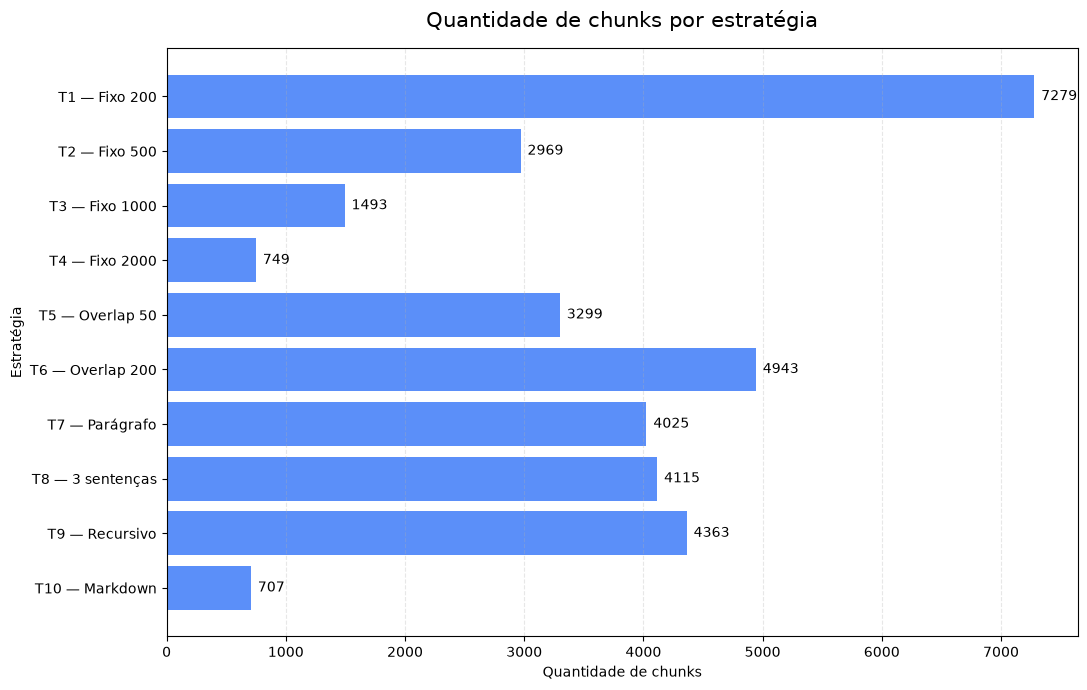

In [145]:
rotulos_testes = {
    1: "T1 — Fixo 200",
    2: "T2 — Fixo 500",
    3: "T3 — Fixo 1000",
    4: "T4 — Fixo 2000",
    5: "T5 — Overlap 50",
    6: "T6 — Overlap 200",
    7: "T7 — Parágrafo",
    8: "T8 — 3 sentenças",
    9: "T9 — Recursivo",
    10: "T10 — Markdown"
}

df_grafico = df_comparacao.copy()

df_grafico["Rótulo"] = df_grafico[
    "Teste"
].map(rotulos_testes)

fig, ax = plt.subplots(
    figsize=(11, 7)
)

barras = ax.barh(
    df_grafico["Rótulo"],
    df_grafico["Quantidade de chunks"],
    color="#5B8FF9"
)

ax.invert_yaxis()

ax.set_title(
    "Quantidade de chunks por estratégia",
    fontsize=15,
    pad=15
)

ax.set_xlabel("Quantidade de chunks")
ax.set_ylabel("Estratégia")

ax.bar_label(
    barras,
    padding=5,
    fontsize=10
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [146]:
testes_esperados = set(
    range(1, 11)
)

testes_executados = set(
    resultados_testes.keys()
)

assert testes_executados == testes_esperados, (
    "Nem todos os dez testes foram executados."
)

assert all(
    len(resultados_testes[numero]) > 0
    for numero in testes_esperados
), "Um ou mais testes não geraram chunks."

print("Validação concluída: os 10 testes geraram chunks.")

Validação concluída: os 10 testes geraram chunks.


## Conclusão

A base analisada foi composta por 12 documentos em Markdown, sendo três
documentos utilizados anteriormente na Aula 02 e nove artigos científicos
convertidos de PDF para Markdown na Aula 04.

A conversão preservou grande parte da estrutura textual, incluindo 708 títulos
e 151 tabelas em formato Markdown. Entretanto, as imagens não foram exportadas
como arquivos ou referências visuais. Foram encontrados 171 marcadores
`<!-- image -->`, indicando que o conversor identificou a posição das figuras,
mas não manteve seu conteúdo visual. Dessa forma, informações presentes
exclusivamente em gráficos, diagramas e imagens podem ter sido perdidas.

Entre as dez estratégias testadas, o Teste 9, utilizando
`RecursiveCharacterTextSplitter`, apresentou o melhor equilíbrio geral para
essa base. A estratégia gerou 4.363 chunks, com média de aproximadamente 331
caracteres, e manteve todos os trechos dentro do limite de 500 caracteres.

O splitter recursivo procura respeitar separadores naturais, como parágrafos,
linhas, sentenças e espaços, antes de recorrer ao corte por caracteres. Por
isso, ele preserva melhor a organização do texto do que as estratégias fixas.

O Teste 10, baseado nos headings do Markdown, preservou melhor a estrutura
semântica das seções e gerou somente 707 chunks. Porém, algumas seções
resultaram em chunks muito extensos, chegando a 52.364 caracteres. Isso pode
prejudicar a recuperação semântica, aumentar o consumo de tokens e misturar
assuntos diferentes no mesmo trecho.

Os testes por parágrafo e por sentenças também preservaram estruturas naturais,
mas produziram chunks com tamanhos muito variáveis. Já os testes fixos
apresentaram tamanhos previsíveis, porém podem cortar palavras, sentenças e
ideias no meio.

Portanto, para esta base, o Teste 9 foi considerado a melhor estratégia geral.
Em uma implementação real de RAG, uma abordagem ainda mais adequada seria
combinar a divisão por headings do Teste 10 com o splitter recursivo do Teste 9,
aplicando o limite de tamanho dentro de cada seção.